In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
from math import ceil
import matplotlib.pyplot as plt

In [123]:
df = pd.read_csv('Dataset/nba_player_basket.csv',low_memory=False)
print(df.head(5))

     gameId      gameDateTimeEst hometeamCity hometeamName  hometeamId  \
0  42500175  2026-04-29 22:00:00  Los Angeles       Lakers  1610612747   
1  42500135  2026-04-29 19:30:00    Cleveland    Cavaliers  1610612739   
2  42500105  2026-04-29 19:00:00      Detroit      Pistons  1610612765   
3  42500155  2026-04-28 21:30:00  San Antonio        Spurs  1610612759   
4  42500125  2026-04-28 20:00:00     New York       Knicks  1610612752   

  awayteamCity   awayteamName  awayteamId  homeScore  awayScore  ...  \
0      Houston        Rockets  1610612745         93         99  ...   
1      Toronto        Raptors  1610612761        125        120  ...   
2      Orlando          Magic  1610612753        116        109  ...   
3     Portland  Trail Blazers  1610612757        114         95  ...   
4      Atlanta          Hawks  1610612737        126         97  ...   

          gameLabel gameSubLabel seriesGameNumber attendance  arenaId  \
0  West First Round       Game 5           Game 5

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73233 entries, 0 to 73232
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gameId            73233 non-null  int64  
 1   gameDateTimeEst   73233 non-null  object 
 2   hometeamCity      73226 non-null  object 
 3   hometeamName      73233 non-null  object 
 4   hometeamId        73233 non-null  int64  
 5   awayteamCity      73226 non-null  object 
 6   awayteamName      73233 non-null  object 
 7   awayteamId        73233 non-null  int64  
 8   homeScore         73233 non-null  int64  
 9   awayScore         73233 non-null  int64  
 10  winner            73233 non-null  int64  
 11  gameType          73233 non-null  object 
 12  gameSubtype       74 non-null     object 
 13  gameLabel         3997 non-null   object 
 14  gameSubLabel      282 non-null    object 
 15  seriesGameNumber  5777 non-null   object 
 16  attendance        1346 non-null   float6

In [109]:
df.shape

(73233, 23)

In [110]:
df.isnull().sum()

gameId                  0
gameDateTimeEst         0
hometeamCity            7
hometeamName            0
hometeamId              0
awayteamCity            7
awayteamName            0
awayteamId              0
homeScore               0
awayScore               0
winner                  0
gameType                0
gameSubtype         73159
gameLabel           69236
gameSubLabel        72951
seriesGameNumber    67456
attendance          71887
arenaId                 0
arenaName           71879
arenaCity           71879
arenaState          71888
officials           71879
gameDate                0
dtype: int64

In [111]:
df = df.drop(columns=['gameSubtype','gameLabel','gameSubLabel','seriesGameNumber','attendance','arenaName','arenaCity','arenaState','officials','arenaId'])
df.head(5)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00
2,42500105,2026-04-29 19:00:00,Detroit,Pistons,1610612765,Orlando,Magic,1610612753,116,109,1610612765,Playoffs,2026-04-29 19:00:00
3,42500155,2026-04-28 21:30:00,San Antonio,Spurs,1610612759,Portland,Trail Blazers,1610612757,114,95,1610612759,Playoffs,2026-04-28 21:30:00
4,42500125,2026-04-28 20:00:00,New York,Knicks,1610612752,Atlanta,Hawks,1610612737,126,97,1610612752,Playoffs,2026-04-28 20:00:00


In [112]:
# handling Feature: hometeamCity
mode_homeTeam = df['hometeamCity'].mode()[0]
df['hometeamCity'].fillna(mode_homeTeam,inplace=True)
df.isnull().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_7876\1416438273.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['hometeamCity'].fillna(mode_homeTeam,inplace=True)


gameId             0
gameDateTimeEst    0
hometeamCity       0
hometeamName       0
hometeamId         0
awayteamCity       7
awayteamName       0
awayteamId         0
homeScore          0
awayScore          0
winner             0
gameType           0
gameDate           0
dtype: int64

In [113]:
# handling Feature: awayteamCity 
mode_awayTeam = df['awayteamCity'].mode()[0]
df['awayteamCity'].fillna(mode_awayTeam,inplace=True)
df.isnull().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_7876\2575765528.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['awayteamCity'].fillna(mode_awayTeam,inplace=True)


gameId             0
gameDateTimeEst    0
hometeamCity       0
hometeamName       0
hometeamId         0
awayteamCity       0
awayteamName       0
awayteamId         0
homeScore          0
awayScore          0
winner             0
gameType           0
gameDate           0
dtype: int64

In [114]:
kolom_id = ['gameId','hometeamId','awayteamId']
df[kolom_id]=df[kolom_id].astype(object)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73233 entries, 0 to 73232
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gameId           73233 non-null  object
 1   gameDateTimeEst  73233 non-null  object
 2   hometeamCity     73233 non-null  object
 3   hometeamName     73233 non-null  object
 4   hometeamId       73233 non-null  object
 5   awayteamCity     73233 non-null  object
 6   awayteamName     73233 non-null  object
 7   awayteamId       73233 non-null  object
 8   homeScore        73233 non-null  int64 
 9   awayScore        73233 non-null  int64 
 10  winner           73233 non-null  int64 
 11  gameType         73233 non-null  object
 12  gameDate         73233 non-null  object
dtypes: int64(3), object(10)
memory usage: 7.3+ MB


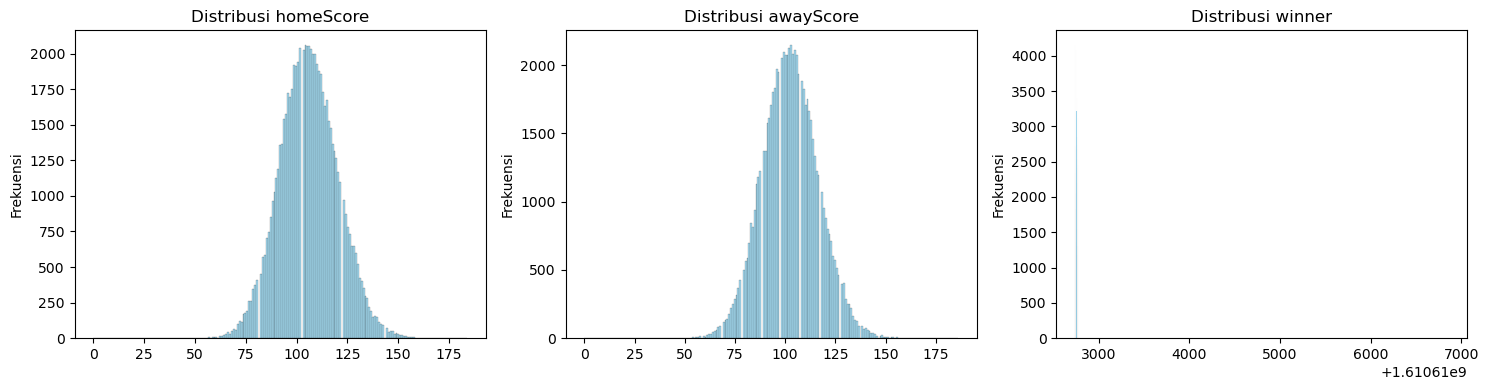

In [115]:
#analisis distribusi  feature numerik
feature_numerik = df.select_dtypes(include=[np.number])
nump_cols = feature_numerik.shape[1]
grid_cols =3
grid_rows = 1

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(5 * grid_cols, 4 * grid_rows))
axes = axes.flatten()  # Meratakan matriks axes menjadi array 1D agar mudah diiterasi
for i, kolom in enumerate(feature_numerik.columns):
    sns.histplot(data=feature_numerik, x=kolom, kde=False, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribusi {kolom}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

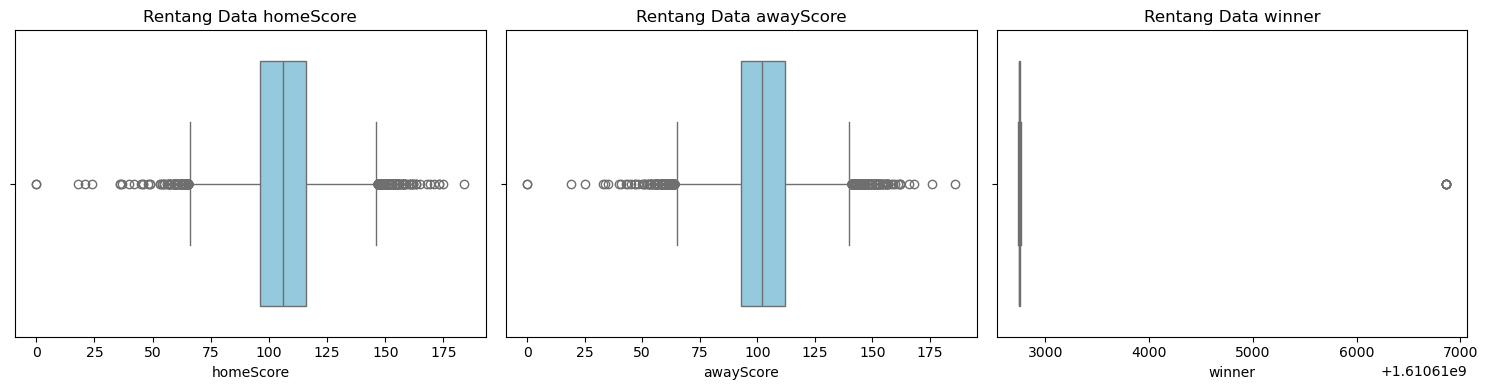

In [116]:
#distribusi feature numerik Boxplot
fig,axes = plt.subplots(grid_rows, grid_cols, figsize=(5 * grid_cols, 4 * grid_rows))
axes = axes.flatten()  # agar jadi 1D
for i, kolom in enumerate(feature_numerik.columns):
    sns.boxplot(data=feature_numerik, x=kolom, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Rentang Data {kolom}')
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel('')   
plt.tight_layout()
plt.show()

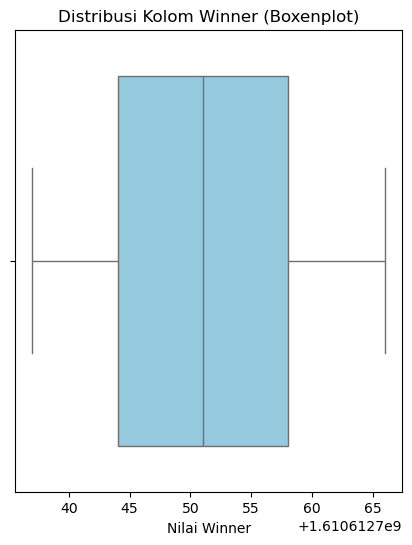

In [117]:
# handling data outlier :winner
quantile_winner = df['winner'].quantile([0.25,0.75])
IQR = quantile_winner.loc[0.75]-quantile_winner.loc[0.25]
batas_bawah = quantile_winner.loc[0.25] - 1.5  * IQR
batas_atas = quantile_winner.loc[0.75] + 1.5 * IQR
df = df[~((df['winner'] < batas_bawah) | (df['winner'] > batas_atas))]

data_winner = df['winner']
plt.figure(figsize=(5, 6))
sns.boxplot(x=data_winner, color='skyblue')
plt.title('Distribusi Kolom Winner (Boxenplot)')
plt.xlabel('Nilai Winner')
plt.ylabel('') 
plt.show()

In [118]:
df.isna().sum()

gameId             0
gameDateTimeEst    0
hometeamCity       0
hometeamName       0
hometeamId         0
awayteamCity       0
awayteamName       0
awayteamId         0
homeScore          0
awayScore          0
winner             0
gameType           0
gameDate           0
dtype: int64

In [119]:
df.duplicated().sum()

np.int64(0)

## Analisis Performa & Keunggulan Tim

   1. Hitung berapa persentase total pertandingan yang berhasil dimenangkan oleh tim tuan rumah (hometeamName). Apakah terdapat indikasi kuat adanya keuntungan bermain di kandang (rasio > 50%)?
   2. Tim manakah (awayteamName) yang memiliki rasio kemenangan tandang tertinggi saat mereka bermain di luar kota asal mereka sendiri?
   3. Jika dihitung berdasarkan rata-rata total skor per pertandingan (homeScore + awayScore), kota mana (hometeamCity) yang pertandingannya paling produktif menghasilkan poin total?
   4. Cari tim yang memiliki nilai standar deviasi selisih skor (selisih absolut antara homeScore dan awayScore) paling kecil saat bermain di kandang sendiri.
   5. Identifikasi pasangan pertandingan kota (hometeamCity vs awayteamCity) yang paling sering bertemu dalam dataset, lalu hitung tim mana yang memimpin rekor kemenangan.

## Analisis Pola Waktu & Karakteristik Kompetisi

   1. Ekstrak nama hari dari gameDate. Apakah rata-rata skor yang dicetak oleh tim tamu cenderung lebih rendah pada hari kerja (weekdays) dibandingkan akhir pekan (weekends)?
   2. Kelompokkan data berdasarkan komponen bulan dari gameDate. Tunjukkan tren rata-rata homeScore dari bulan ke bulan menggunakan teknik agregasi data.
   3. Ekstrak komponen jam dari gameDateTimeEst. Apakah pertandingan yang dimulai di atas jam 18:00 (malam hari) memiliki rata-rata selisih skor yang lebih ketat dibanding laga siang hari?
   4. Bandingkan nilai median dari total skor pertandingan untuk setiap kategori di gameType. Apakah tipe pertandingan tertentu terbukti berjalan lebih defensif (skor lebih rendah)?
   5. Identifikasi tim yang memiliki persentase kemenangan tertinggi khusus pada gameType yang bukan musim reguler (misal: kategori playoff atau turnamen).

## Analisis Distribusi Skor, Kontribusi Poin, dan Dominasi Klasemen

   1. Buat fitur baru yang menghitung persentase kontribusi poin tim tuan rumah terhadap total skor pertandingan (homeScore / (homeScore + awayScore)). Tim mana yang memiliki rasio kontribusi tertinggi saat bermain di kandang?
   2. Hitung rata-rata skor yang dicetak (points scored) dan rata-rata kebobolan (points allowed) untuk setiap tim di sepanjang dataset. Tampilkan 3 tim dengan produktivitas serangan terbaik dan 3 tim dengan pertahanan terkuat.
   3. Hitung selisih skor absolut antara kedua tim di setiap laga. Tentukan nilai rata-rata, median, dan modus dari selisih skor tersebut untuk melihat seberapa ketat peta persaingan liga secara umum.
   4. Gunakan kolom winner untuk menghitung total jumlah kemenangan dari setiap tim (gabungan saat menjadi home maupun away). Urutkan tim dari yang mengoleksi kemenangan terbanyak hingga tersedikit.
   5. Berapa persen pertandingan dalam dataset yang berakhir dengan selisih skor sangat tipis (misal $\le 3$ poin)? Kelompokkan hasil persentase ini berdasarkan masing-masing gameType untuk melihat di fase mana laga sengit paling sering terjadi.


In [121]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,21.199881,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,21.199881,Playoffs,2026-04-29 19:30:00


## Analisis Performa & Keunggulan Tim

   1. Hitung berapa persentase total pertandingan yang berhasil dimenangkan oleh tim tuan rumah (hometeamName). Apakah terdapat indikasi kuat adanya keuntungan bermain di kandang (rasio > 50%)?
   2. Tim manakah (awayteamName) yang memiliki rasio kemenangan tandang tertinggi saat mereka bermain di luar kota asal mereka sendiri?
   3. Jika dihitung berdasarkan rata-rata total skor per pertandingan (homeScore + awayScore), kota mana (hometeamCity) yang pertandingannya paling produktif menghasilkan poin total?
   4. Cari tim yang memiliki nilai standar deviasi selisih skor (selisih absolut antara homeScore dan awayScore) paling kecil saat bermain di kandang sendiri.
   5. Identifikasi pasangan pertandingan kota (hometeamCity vs awayteamCity) yang paling sering bertemu dalam dataset, lalu hitung tim mana yang memimpin rekor kemenangan.

In [127]:
# soal nomor 1
# 1. Hitung berapa persentase total pertandingan yang berhasil dimenangkan oleh tim tuan rumah (hometeamName). Apakah terdapat indikasi kuat adanya keuntungan bermain di kandang (rasio > 50%)?
data =  df[['homeScore','hometeamName']].copy()
mean_allWinner = data['homeScore'].mean()
totals_match = data.groupby('hometeamName')['homeScore'].mean().reset_index().round(2)
totals_match['ration'] = ((totals_match['homeScore'] / mean_allWinner) * 100).round(2)
totals_match

,hometeamName,homeScore,ration
0,76ers,106.92,100.84
1,Blackhawks,86.41,81.49
2,Bobcats,95.92,90.46
3,Braves,107.08,100.99
4,Bucks,107.04,100.95
5,Bullets,108.62,102.44
6,Bulls,103.85,97.94
7,Cavaliers,103.64,97.74
8,Celtics,108.42,102.25
9,Clippers,104.75,98.79
